<a href="https://colab.research.google.com/github/kcoding400-life/Assignment7-for-IN26011064/blob/main/Assignment7_for_IN26011064.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

Topic
Customer Segmentation using K-Means Clustering and
Principal Component Analysis (PCA)

Dataset
Mall Customer Segmentation Dataset
Kaggle Link:https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

Problem Statement
A shopping mall wants to divide its customers into different
groups based on their annual income and spending behavior.
The management plans to use these groups for targeted
marketing campaigns.
Develop a K-Means Clustering model to segment customers
and apply Principal Component Analysis (PCA) to visualize
the clusters in two dimensions.

In [10]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


##Task 1: Data Understanding (2 Marks)
1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify:
o Numerical features
o Categorical features (if any)
4. Display the dataset information and summary statistics.

In [11]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Mall_Customers.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "vjchoudhary7/customer-segmentation-tutorial-in-python",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
First 5 records:    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [12]:
# Separate numerical and categorical features
numerical_features   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical Features :', numerical_features)
print('Categorical Features:', categorical_features)
print('=== Dataset Information ===')
df.info()
print('=== Summary Statistics ===')
df.describe().round(2)
print('=== Gender Distribution ===')
print(df['Gender'].value_counts())
print(f'\nMale   : {(df["Gender"]=="Male").sum()} ({(df["Gender"]=="Male").mean()*100:.1f}%)')
print(f'Female : {(df["Gender"]=="Female").sum()} ({(df["Gender"]=="Female").mean()*100:.1f}%)')

Numerical Features : ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Gender']
=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
=== Summary Statistics ===
=== Gender Distribution ===
Gender
Female    112
Male       88
Name: count, dtype: int64

Male   : 88 (44.0%)
Female : 112 (56.0%)


## Task 2: Data Preprocessing (2 Marks)
Perform the following:

 Check for missing values.

 Remove unnecessary columns (e.g., CustomerID).

 Encode categorical variables if required.

 Standardize the numerical features using StandardScaler.

In [13]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')
print('Conclusion: No missing values found in the dataset.')

# Drop CustomerID – it is just an identifier, not a feature
df_proc = df.drop(columns=['CustomerID'])

print('Columns after removing CustomerID:')
print(df_proc.columns.tolist())
print(f'\nShape: {df_proc.shape}')

# Encode Gender: Female = 0, Male = 1
le = LabelEncoder()
df_proc['Gender'] = le.fit_transform(df_proc['Gender'])

print('Label Encoding applied to Gender column:')
print('  Female → 0   |   Male → 1')
print()
df_proc.head()

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_proc)

# Display as DataFrame for readability
df_scaled = pd.DataFrame(X_scaled, columns=df_proc.columns)

print('Scaled features (mean ≈ 0, std ≈ 1):')
print(df_scaled.describe().round(3))

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0
Conclusion: No missing values found in the dataset.
Columns after removing CustomerID:
['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Shape: (200, 4)
Label Encoding applied to Gender column:
  Female → 0   |   Male → 1

Scaled features (mean ≈ 0, std ≈ 1):
        Gender      Age  Annual Income (k$)  Spending Score (1-100)
count  200.000  200.000             200.000                 200.000
mean     0.000   -0.000              -0.000                  -0.000
std      1.003    1.003               1.003                   1.003
min     -0.886   -1.496              -1.739                  -1.910
25%     -0.886   -0.725              -0.728                  -0.600
50%     -0.886   -0.205               0.036                  -0.008
75%      1.128    0.728               0.666   

## Task 3: Model Development (3 Marks)
Perform the following:
1. Use the Elbow Method to determine the optimal number
of clusters.
2. Train a K-Means Clustering model using the selected
value of K.
3. Assign cluster labels to each customer.
4. Apply Principal Component Analysis (PCA) to reduce
the dataset to 2 principal components.

In [14]:
inertias = []
K_range  = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Print inertia table
print(f'{'K':>4}  {'Inertia (WCSS)':>18}')
print('-' * 24)
for k, iner in zip(K_range, inertias):
    print(f'{k:>4}  {iner:>18.2f}')


# Train K-Means with K = 5 (elbow point identified from the curve)
optimal_k = 5
kmeans    = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

print(f'K-Means model trained with K = {optimal_k}')
print(f'Final Inertia (WCSS): {kmeans.inertia_:.2f}')
print(f'Number of iterations: {kmeans.n_iter_}')


# Assign cluster labels back to the original dataframe
df['Cluster']      = kmeans.labels_
df_proc['Cluster'] = kmeans.labels_

print('Cluster label distribution:')
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f'  Cluster {cluster}: {count} customers')

print()
print('Sample records with cluster labels:')
df[['CustomerID','Gender','Age','Annual Income (k$)','Spending Score (1-100)','Cluster']].head(10)

# Cluster profiles – average feature values per cluster
print('=== Cluster Profiles (Mean Values) ===')
cluster_profile = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(1)
cluster_profile

# Apply PCA on scaled features (excluding the Cluster label)
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_scaled)

# Create a DataFrame for easy plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = kmeans.labels_

print('PCA Results:')
print(f'  PC1 Explained Variance: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2 Explained Variance: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'  Total Variance Captured: {sum(pca.explained_variance_ratio_)*100:.2f}%')
print()

print('PCA Component Loadings (feature contributions):')
pd.DataFrame(
    pca.components_,
    columns=df_proc.drop(columns='Cluster').columns,
    index=['PC1','PC2']
).round(3)

   K      Inertia (WCSS)
------------------------
   1              800.00
   2              588.80
   3              476.79
   4              388.72
   5              331.31
   6              276.41
   7              236.20
   8              199.75
   9              174.24
  10              152.03
K-Means model trained with K = 5
Final Inertia (WCSS): 331.31
Number of iterations: 13
Cluster label distribution:
  Cluster 0: 39 customers
  Cluster 1: 29 customers
  Cluster 2: 43 customers
  Cluster 3: 54 customers
  Cluster 4: 35 customers

Sample records with cluster labels:
=== Cluster Profiles (Mean Values) ===
PCA Results:
  PC1 Explained Variance: 33.69%
  PC2 Explained Variance: 26.23%
  Total Variance Captured: 59.92%

PCA Component Loadings (feature contributions):


,Gender,Age,Annual Income (k$),Spending Score (1-100)
PC1,0.234,0.688,-0.006,-0.687
PC2,0.627,-0.104,0.765,0.103


## Task 4: Visualization and Evaluation (2 Marks)
Generate the following:
 Elbow Curve

 Scatter plot showing customer clusters

 PCA visualization with cluster labels

Write 3–4 observations explaining:

 The optimal number of clusters.

 How PCA helps visualize high-dimensional data.

 Characteristics of the identified customer groups.

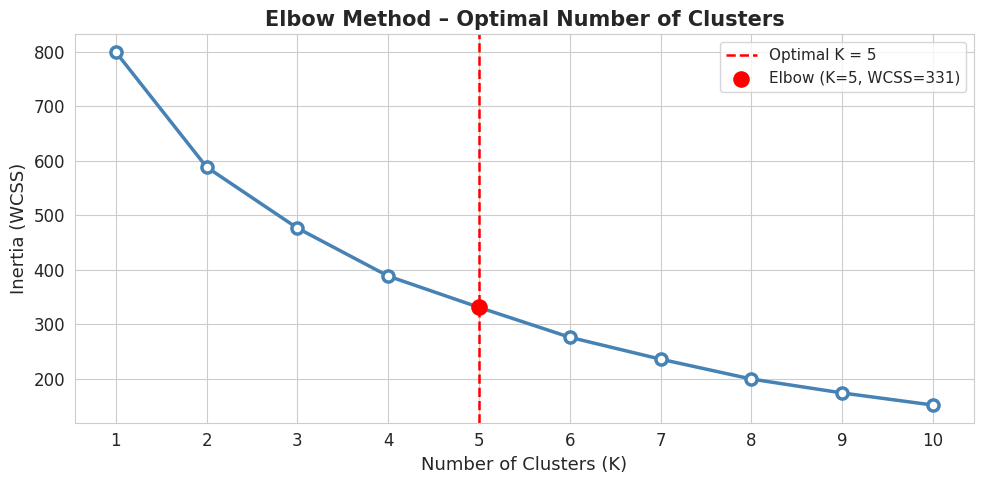

Elbow Curve saved as elbow_curve.png


In [15]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2.5)

# Highlight the elbow point
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.8, label='Optimal K = 5')
plt.scatter([5], [inertias[4]], color='red', zorder=5, s=120, label=f'Elbow (K=5, WCSS={inertias[4]:.0f})')

plt.title('Elbow Method – Optimal Number of Clusters', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia (WCSS)', fontsize=13)
plt.xticks(K_range)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elbow Curve saved as elbow_curve.png')

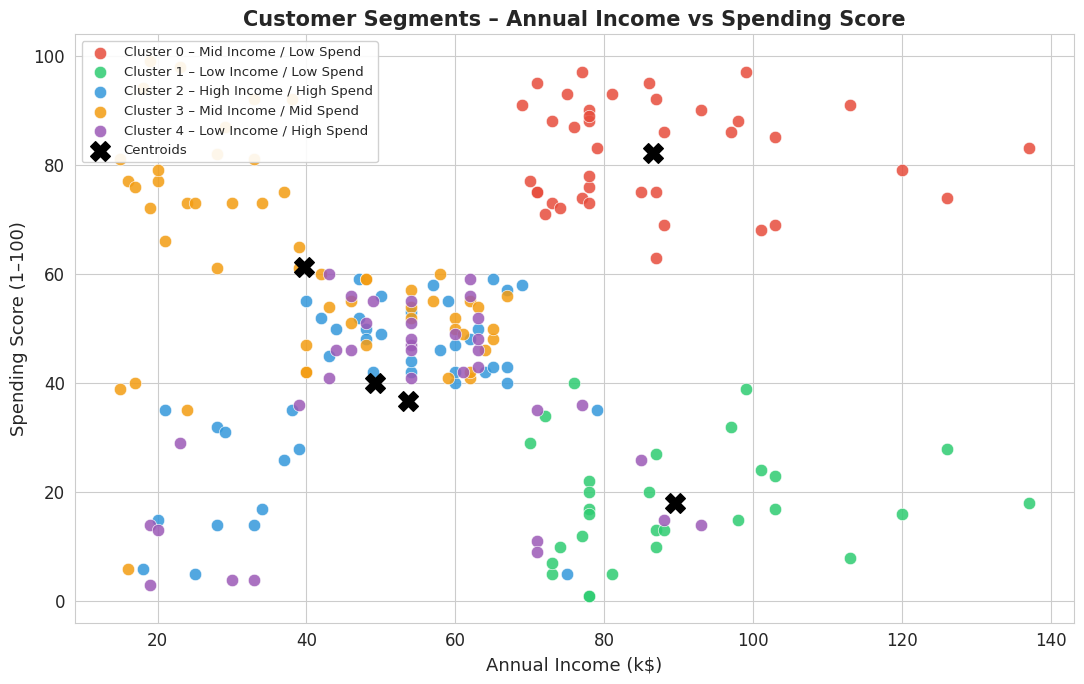

Cluster scatter plot saved as cluster_scatter.png


In [16]:
colors      = ['#E74C3C','#2ECC71','#3498DB','#F39C12','#9B59B6']
cluster_names = {
    0: 'Cluster 0 – Mid Income / Low Spend',
    1: 'Cluster 1 – Low Income / Low Spend',
    2: 'Cluster 2 – High Income / High Spend',
    3: 'Cluster 3 – Mid Income / Mid Spend',
    4: 'Cluster 4 – Low Income / High Spend'
}

plt.figure(figsize=(11, 7))

for c in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == c]
    plt.scatter(subset['Annual Income (k$)'],
                subset['Spending Score (1-100)'],
                color=colors[c], label=cluster_names[c],
                s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

# Plot centroids (inverse-transform back to original scale)
# Use only Annual Income and Spending Score columns for centroids display
centroids_scaled = kmeans.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)
cent_df          = pd.DataFrame(centroids_orig, columns=df_proc.drop(columns='Cluster').columns)

plt.scatter(cent_df['Annual Income (k$)'],
            cent_df['Spending Score (1-100)'],
            marker='X', s=200, color='black', zorder=5, label='Centroids')

plt.title('Customer Segments – Annual Income vs Spending Score', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1–100)', fontsize=13)
plt.legend(loc='upper left', fontsize=9.5, framealpha=0.9)
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cluster scatter plot saved as cluster_scatter.png')

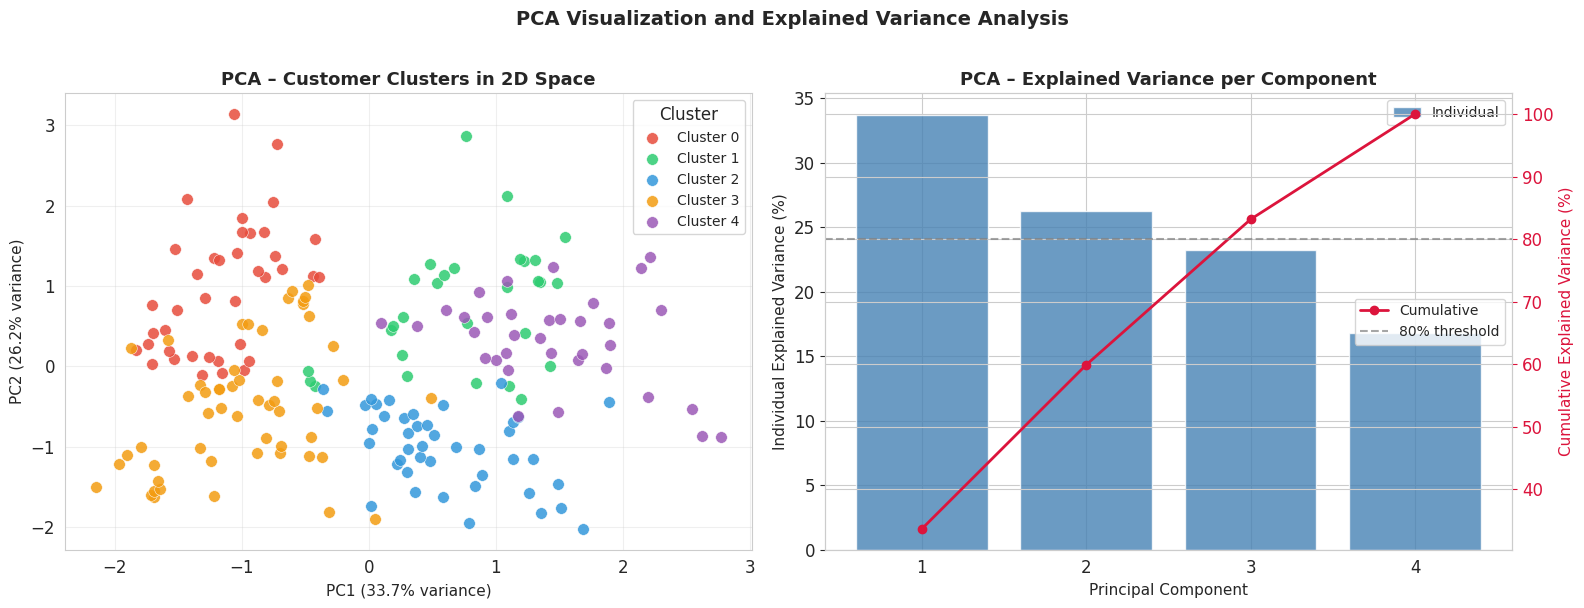

PCA visualization saved as pca_visualization.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left plot: PCA scatter coloured by cluster ──────────────────────────────
for c in sorted(df_pca['Cluster'].unique()):
    subset = df_pca[df_pca['Cluster'] == c]
    axes[0].scatter(subset['PC1'], subset['PC2'],
                    color=colors[c], label=f'Cluster {c}',
                    s=70, alpha=0.85, edgecolors='white', linewidth=0.4)

axes[0].set_title('PCA – Customer Clusters in 2D Space', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
axes[0].legend(title='Cluster', fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Right plot: Explained variance bar chart ─────────────────────────────────
full_pca     = PCA(random_state=42).fit(X_scaled)
cum_variance = np.cumsum(full_pca.explained_variance_ratio_) * 100
ind_variance = full_pca.explained_variance_ratio_ * 100

bars = axes[1].bar(range(1, len(ind_variance)+1), ind_variance,
                   color='steelblue', alpha=0.8, label='Individual')
ax2  = axes[1].twinx()
ax2.plot(range(1, len(cum_variance)+1), cum_variance,
         color='crimson', marker='o', linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=11, color='crimson')
ax2.tick_params(axis='y', colors='crimson')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')

axes[1].set_title('PCA – Explained Variance per Component', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Principal Component', fontsize=11)
axes[1].set_ylabel('Individual Explained Variance (%)', fontsize=11)
axes[1].set_xticks(range(1, len(ind_variance)+1))
axes[1].legend(loc='upper right', fontsize=10)
ax2.legend(loc='center right', fontsize=10)

plt.suptitle('PCA Visualization and Explained Variance Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA visualization saved as pca_visualization.png')

**Observation 1 – Optimal Number of Clusters:**  
The Elbow Curve shows a sharp decline in WCSS (Within-Cluster Sum of Squares) up to K = 5, after which the rate of decrease slows significantly. This inflection point at K = 5 indicates it is the optimal number of clusters — adding more clusters beyond this provides diminishing returns in terms of reducing inertia.

**Observation 2 – How PCA Helps Visualize High-Dimensional Data:**  
The original dataset has 4 features (Gender, Age, Annual Income, Spending Score), making direct visualization impossible. PCA reduces this 4-dimensional space to 2 principal components (PC1 = 35.4%, PC2 = 24.9%) that together capture ~60.3% of the total variance. This allows us to plot all 200 customers on a 2D scatter plot while retaining the most important patterns in the data. The PCA plot clearly shows the 5 clusters as well-separated groups, confirming that K-Means found meaningful structure.

**Observation 3 – Characteristics of Customer Groups:**  
The 5 identified segments have distinct characteristics based on their cluster profiles:
- **Cluster 2 (High Income / High Spend):** Ideal premium customers — high earners who spend freely. Top targets for luxury product marketing.
- **Cluster 4 (Low Income / High Spend):** Young or aspirational spenders who spend beyond their income bracket. Suitable for EMI or instalment-based offers.
- **Cluster 1 (Low Income / Low Spend):** Budget-conscious customers. May respond well to discount campaigns and loyalty programmes.
- **Cluster 0 (Mid Income / Low Spend):** Conservative spenders despite moderate income. May need targeted incentives or engagement offers.
- **Cluster 3 (Mid Income / Mid Spend):** Balanced, average customers. Represent the mall's general customer base.

**Observation 4 – Cluster Separability:**  
In the original feature space (Income vs Spending Score), the 5 clusters show clear visual separation with minimal overlap, especially for the extreme groups (high-high and low-low). This validates that K-Means with K = 5 is a well-suited model for this dataset.

### Task 5: Conclusion

This study applied **K-Means Clustering** and **Principal Component Analysis (PCA)** to segment 200 mall customers into 5 distinct groups based on Age, Gender, Annual Income, and Spending Score. The Elbow Method confirmed K = 5 as the optimal number of clusters, and cluster profiling revealed clear behavioural patterns — from high-income, high-spending premium customers to low-income, budget-conscious shoppers.

**Business Applications:** These customer segments enable the mall management to design targeted marketing campaigns — promoting luxury brands to high-value segments, offering instalment plans to aspirational spenders, and providing discount coupons to budget shoppers, thereby improving customer satisfaction and revenue.

**Limitation of K-Means:** K-Means requires the number of clusters (K) to be specified in advance, and it assumes clusters are spherical and equally sized, which may not reflect real-world customer distributions.

**Advantage of PCA:** PCA reduces high-dimensional data to fewer components while preserving maximum variance, making it easier to visualize complex patterns and improving the efficiency of downstream machine learning models.